In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import re


# ============================================================
# 1. Paths and orders
# ============================================================

BASE_DATE = "JUN11"

pred_dir = Path(f"_json/_run/{BASE_DATE}/_prediction_daily")

eplus_prediction_path = (
    pred_dir / "prediction_daily_EPlus_4P_FEBMAR.csv"
)

eplus_ecm_path = (
    pred_dir / "ecm_savings_daily_EPlus_4P_FEBMAR_LoD1to3.csv"
)

rc_run_ids = [
    "ETHlib_default_occ",
    "ETHlib_ONSITE_occ",
    "ETHlib_bldg_LoD_Y",
    "ETHlib_3R2C_default_occ",
    "ETHlib_3R2C_ONSITE_occ",
    "ETHlib_3R2C_bldg_LoD_Y",
]

engine_order = ["EnergyPlus", "5R1C", "3R2C"]
quality_order = ["LoD-1", "LoD-2", "LoD-3"]
common_ecm_order = ["O&M-1", "O&M-2", "O&M-3", "O&M-4"]

quality_display_map = {
    "LoD-1": "$LoD_d$=1",
    "LoD-2": "$LoD_d$=2",
    "LoD-3": "$LoD_d$=3",
}

ecm_label_map = {
    "O&M-1": "O&M-1:\nSetpoint",
    "O&M-2": "O&M-2:\nSetpoint\n+ schedule",
    "O&M-3": "O&M-3:\nSchedule",
    "O&M-4": "O&M-4:\nSchedule\n+ window",
}
# ============================================================
# 2. Harmonisation maps
# ============================================================

quality_map = {
    # EnergyPlus
    "beta": "LoD-1",
    "gamma": "LoD-2",
    "yearly": "LoD-3",
    "_beta": "LoD-1",
    "_gamma": "LoD-2",
    "bY": "LoD-3",

    # RC
    "default_occ": "LoD-1",
    "ONSITE_occ": "LoD-2",
    "bldg_LoD_Y": "LoD-3",
}

eplus_ecm_to_common = {
    "O&M-1": "O&M-1",
    "O&M-2": "O&M-2",
    "O&M-3": "O&M-3",
    "O&M-5": "O&M-4",
    "O&M-4": "E+ only: O&M-4",
    "O&M-6": "E+ only: O&M-6",
}

rc_ecm_to_common = {
    "ECM-1_setpoint_19C": "O&M-1",
    "ECM-3_setpoint_19C_reschedule_8_8_8": "O&M-2",
    "ECM-2_reschedule_8_8_8": "O&M-3",
    "ECM-4_setpoint_19C_default_infiltration": "O&M-4",
    "ECM-5_reschedule_8_8_8_default_infiltration": "RC only: setpoint + default infiltration",
}


def infer_rc_engine_and_quality(run_id):
    if "3R2C" in run_id:
        engine = "3R2C"
    else:
        engine = "5R1C"

    if "default_occ" in run_id:
        data_quality = "LoD-1"
    elif "ONSITE_occ" in run_id:
        data_quality = "LoD-2"
    elif "bldg_LoD_Y" in run_id:
        data_quality = "LoD-3"
    else:
        data_quality = np.nan

    return engine, data_quality


def sample_sort_value(sample_id):
    nums = re.findall(r"\d+", str(sample_id))
    return int(nums[-1]) if nums else 0

In [2]:
from pathlib import Path
import pandas as pd


# ============================================================
# 0. Settings
# ============================================================

BASE_DATE = "JUN11"

pred_dir = Path(f"_json/_run/{BASE_DATE}/_prediction_daily")
eplus_path = pred_dir / "prediction_daily_EPlus_4P_FEBMAR.csv"

rc_run_ids = [
    "ETHlib_default_occ",
    "ETHlib_ONSITE_occ",
    "ETHlib_bldg_LoD_Y",
    "ETHlib_3R2C_default_occ",
    "ETHlib_3R2C_ONSITE_occ",
    "ETHlib_3R2C_bldg_LoD_Y",
]


# ============================================================
# 1. Group / label helpers
# ============================================================

label_map = {
    "_beta": r"LoD-1: $ihg^{1}_{1}$",
    "_gamma": r"LoD-2: $ihg^{2}_{1}$",
    "bY": r"LoD-3: $ihg^{3}_{1}$",
    "default_occ": "LoD-1: default occupancy",
    "ONSITE_occ": "LoD-2: on-site occupancy",
    "bldg_LoD_Y": "LoD-3: building LoD-Y occupancy",
}


def infer_eplus_group_from_text(text):
    text = str(text)

    if "4P__beta" in text or "_beta" in text:
        return "_beta"
    if "4P__gamma" in text or "_gamma" in text:
        return "_gamma"
    if "4P_bY" in text or "bY" in text:
        return "bY"

    return "unknown"


def infer_rc_model_name(run_label):
    if "ETHlib_3R2C" in run_label:
        return "3R2C"
    if "ETHlib" in run_label:
        return "5R1C"

    return "RC"


def infer_rc_group(run_label):
    if "default_occ" in run_label:
        return "default_occ"
    if "ONSITE_occ" in run_label:
        return "ONSITE_occ"
    if "bldg_LoD_Y" in run_label:
        return "bldg_LoD_Y"

    return "unknown"


# ============================================================
# 2. Load original E+ prediction_daily
# ============================================================

def load_original_eplus_prediction_daily(path):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Missing E+ file: {path}")

    df = pd.read_csv(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    if "heating_energy" in df.columns and "sim_heating" not in df.columns:
        df = df.rename(columns={"heating_energy": "sim_heating"})

    if "Metering" in df.columns and "metered_heating" not in df.columns:
        df = df.rename(columns={"Metering": "metered_heating"})

    df["source"] = "EPlus"
    df["experiment_id"] = df.get("experiment_id", "EPlus_4P_FEBMAR")
    df["model_name"] = "EnergyPlus"

    df["scenario_group"] = df.apply(
        lambda row: infer_eplus_group_from_text(
            " ".join([
                str(row.get("scenario_group", "")),
                str(row.get("scenario_label", "")),
                str(row.get("sample_id", "")),
                str(row.get("experiment_id", "")),
            ])
        ),
        axis=1,
    )

    df["scenario_label"] = df["scenario_group"].map(label_map)

    keep_cols = [
        "source",
        "experiment_id",
        "model_name",
        "scenario_group",
        "scenario_label",
        "sample_id",
        "timestamp",
        "sim_heating",
        "metered_heating",
    ]

    missing = [c for c in keep_cols if c not in df.columns]
    if missing:
        raise ValueError(f"E+ file is missing columns: {missing}")

    return df[keep_cols].copy()


# ============================================================
# 3. Load original six RC prediction_daily files
# ============================================================

def load_original_rc_prediction_daily(base_date, rc_run_ids, metered_by_date=None):
    dfs = []
    missing_files = []

    for run_id in rc_run_ids:
        run_label = f"{base_date}__{run_id}"

        path = (
            Path(f"_json/_run/{run_label}")
            / "_outcome"
            / run_label
            / "baseline_prediction_daily.csv"
        )

        if not path.exists():
            missing_files.append(path)
            continue

        df = pd.read_csv(path)
        df["timestamp"] = pd.to_datetime(df["timestamp"])

        if "heating_energy" in df.columns and "sim_heating" not in df.columns:
            df = df.rename(columns={"heating_energy": "sim_heating"})

        if "sim_heating" not in df.columns:
            raise ValueError(
                f"{path} has no 'heating_energy' or 'sim_heating' column."
            )

        scenario_group = infer_rc_group(run_label)

        df["source"] = "RC"
        df["experiment_id"] = run_label
        df["model_name"] = infer_rc_model_name(run_label)
        df["scenario_group"] = scenario_group
        df["scenario_label"] = label_map.get(scenario_group, scenario_group)

        if "metered_heating" not in df.columns:
            if metered_by_date is not None:
                df = df.merge(
                    metered_by_date,
                    on="timestamp",
                    how="left",
                )
            else:
                df["metered_heating"] = pd.NA

        keep_cols = [
            "source",
            "experiment_id",
            "model_name",
            "scenario_group",
            "scenario_label",
            "sample_id",
            "timestamp",
            "sim_heating",
            "metered_heating",
        ]

        dfs.append(df[keep_cols].copy())

    if missing_files:
        print("[WARN] Missing RC files:")
        for path in missing_files:
            print("   ", path)

    if not dfs:
        raise ValueError("No RC prediction files were loaded.")

    return pd.concat(dfs, ignore_index=True)


# ============================================================
# 4. Build prediction_daily from originals only
# ============================================================

prediction_daily_eplus = load_original_eplus_prediction_daily(eplus_path)

metered_by_date = (
    prediction_daily_eplus[["timestamp", "metered_heating"]]
    .dropna()
    .drop_duplicates(subset=["timestamp"])
    .copy()
)

prediction_daily_rc = load_original_rc_prediction_daily(
    base_date=BASE_DATE,
    rc_run_ids=rc_run_ids,
    metered_by_date=metered_by_date,
)

prediction_daily = pd.concat(
    [
        prediction_daily_eplus,
        prediction_daily_rc,
    ],
    ignore_index=True,
)

prediction_daily = prediction_daily.sort_values(
    [
        "source",
        "model_name",
        "scenario_group",
        "sample_id",
        "timestamp",
    ]
).reset_index(drop=True)


# ============================================================
# 5. Check
# ============================================================

display(
    prediction_daily.groupby(
        ["source", "model_name", "scenario_group"]
    )["sample_id"].nunique()
)

def standardise_ecm_columns(df):
    df = df.copy()

    rename_map = {}

    if "ECM" in df.columns and "ecm" not in df.columns:
        rename_map["ECM"] = "ecm"

    if "ecm_name" in df.columns and "ecm" not in df.columns:
        rename_map["ecm_name"] = "ecm"

    if "Saving_abs" in df.columns and "saving_abs" not in df.columns:
        rename_map["Saving_abs"] = "saving_abs"

    if "Saving_rel" in df.columns and "saving_rel" not in df.columns:
        rename_map["Saving_rel"] = "saving_rel"

    if "saving_abs_pct" in df.columns and "saving_rel" not in df.columns:
        rename_map["saving_abs_pct"] = "saving_rel"

    df = df.rename(columns=rename_map)

    return df


def load_ecm_savings_common_all():
    all_ecm = []

    # --------------------------------------------------------
    # EnergyPlus ECM savings
    # --------------------------------------------------------

    eplus_df = pd.read_csv(eplus_ecm_path)
    eplus_df = standardise_ecm_columns(eplus_df)

    eplus_df["source"] = "EPlus"
    eplus_df["engine"] = "EnergyPlus"

    if "data_quality" not in eplus_df.columns:
        eplus_df["data_quality"] = eplus_df["scenario_group"].map(quality_map)

    eplus_df["ecm_common"] = eplus_df["ecm"].map(eplus_ecm_to_common)

    all_ecm.append(eplus_df)

    # --------------------------------------------------------
    # RC ECM savings
    # --------------------------------------------------------

    for run_id in rc_run_ids:
        path = (
            Path(f"_json/_run/{BASE_DATE}__{run_id}")
            / "_outcome"
            / f"{BASE_DATE}__{run_id}"
            / "ecm_savings_daily.csv"
        )

        rc_df = pd.read_csv(path)
        rc_df = standardise_ecm_columns(rc_df)

        engine, data_quality = infer_rc_engine_and_quality(run_id)

        rc_df["source"] = "RC"
        rc_df["experiment_id"] = f"{BASE_DATE}__{run_id}"
        rc_df["engine"] = engine
        rc_df["data_quality"] = data_quality
        rc_df["scenario_group"] = run_id.replace("ETHlib_3R2C_", "").replace("ETHlib_", "")
        rc_df["ecm_common"] = rc_df["ecm"].map(rc_ecm_to_common)

        all_ecm.append(rc_df)

    ecm_savings_common = pd.concat(all_ecm, ignore_index=True)

    ecm_savings_common["sample_id"] = ecm_savings_common["sample_id"].astype(str)

    ecm_savings_common = ecm_savings_common[
        ecm_savings_common["engine"].isin(engine_order)
        & ecm_savings_common["data_quality"].isin(quality_order)
        & ecm_savings_common["ecm_common"].isin(common_ecm_order)
    ].copy()

    ecm_savings_common["engine"] = pd.Categorical(
        ecm_savings_common["engine"],
        categories=engine_order,
        ordered=True,
    )

    ecm_savings_common["data_quality"] = pd.Categorical(
        ecm_savings_common["data_quality"],
        categories=quality_order,
        ordered=True,
    )

    ecm_savings_common["ecm_common"] = pd.Categorical(
        ecm_savings_common["ecm_common"],
        categories=common_ecm_order,
        ordered=True,
    )

    ecm_savings_common["ecm_label"] = ecm_savings_common["ecm_common"].map(ecm_label_map)
    ecm_savings_common["_sample_sort"] = ecm_savings_common["sample_id"].map(sample_sort_value)

    ecm_savings_common = (
        ecm_savings_common
        .sort_values(
            [
                "ecm_common",
                "engine",
                "data_quality",
                "_sample_sort",
            ]
        )
        .drop(columns="_sample_sort")
        .reset_index(drop=True)
    )

    return ecm_savings_common


ecm_savings_common = load_ecm_savings_common_all()

display(ecm_savings_common.head())

display(
    ecm_savings_common
    .groupby(["ecm_common", "engine", "data_quality"], observed=True)["sample_id"]
    .nunique()
)

source  model_name  scenario_group
EPlus   EnergyPlus  _beta             10
                    _gamma            10
                    bY                10
                    unknown           20
RC      3R2C        ONSITE_occ        10
                    bldg_LoD_Y        10
                    default_occ       10
        5R1C        ONSITE_occ        10
                    bldg_LoD_Y        10
                    default_occ       10
Name: sample_id, dtype: int64

,source,experiment_id,engine,model_name,scenario,scenario_group,scenario_label,baseline,ecm,sample_id,...,period_end,freq,baseline_energy,ecm_energy,saving_abs,saving_frac,saving_rel,data_quality,ecm_common,ecm_label
0,EPlus,EPlus_4P_FEBMAR_beta,EnergyPlus,EnergyPlus,beta,_beta,LoD-1: $ihg^{1}_{1}$,LoD-1: $ihg^{1}_{1}$,O&M-1,sample_001,...,2023-03-17,daily,19.650244,17.412171,2.238073,0.113895,11.389545,LoD-1,O&M-1,O&M-1:\nSetpoint
1,EPlus,EPlus_4P_FEBMAR_beta,EnergyPlus,EnergyPlus,beta,_beta,LoD-1: $ihg^{1}_{1}$,LoD-1: $ihg^{1}_{1}$,O&M-1,sample_002,...,2023-03-17,daily,19.991976,17.595883,2.396093,0.119853,11.985274,LoD-1,O&M-1,O&M-1:\nSetpoint
2,EPlus,EPlus_4P_FEBMAR_beta,EnergyPlus,EnergyPlus,beta,_beta,LoD-1: $ihg^{1}_{1}$,LoD-1: $ihg^{1}_{1}$,O&M-1,sample_003,...,2023-03-17,daily,19.994619,18.142892,1.851728,0.092611,9.261130,LoD-1,O&M-1,O&M-1:\nSetpoint
3,EPlus,EPlus_4P_FEBMAR_beta,EnergyPlus,EnergyPlus,beta,_beta,LoD-1: $ihg^{1}_{1}$,LoD-1: $ihg^{1}_{1}$,O&M-1,sample_004,...,2023-03-17,daily,18.507431,16.657681,1.849751,0.099946,9.994637,LoD-1,O&M-1,O&M-1:\nSetpoint
4,EPlus,EPlus_4P_FEBMAR_beta,EnergyPlus,EnergyPlus,beta,_beta,LoD-1: $ihg^{1}_{1}$,LoD-1: $ihg^{1}_{1}$,O&M-1,sample_005,...,2023-03-17,daily,20.684093,18.733932,1.950161,0.094283,9.428311,LoD-1,O&M-1,O&M-1:\nSetpoint


ecm_common  engine      data_quality
O&M-1       EnergyPlus  LoD-1           10
                        LoD-2           10
                        LoD-3           10
            5R1C        LoD-1           10
                        LoD-2           10
                        LoD-3           10
            3R2C        LoD-1           10
                        LoD-2           10
                        LoD-3           10
O&M-2       EnergyPlus  LoD-1           10
                        LoD-2           10
                        LoD-3           10
            5R1C        LoD-1           10
                        LoD-2           10
                        LoD-3           10
            3R2C        LoD-1           10
                        LoD-2           10
                        LoD-3           10
O&M-3       EnergyPlus  LoD-1           10
                        LoD-2           10
                        LoD-3           10
            5R1C        LoD-1           10
                 

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr


# ============================================================
# 1. Build RQ2 dataset: prediction metric + ECM saving estimate
# ============================================================

def make_rq2_correlation_dataset(
    metric_df,
    ecm_savings_common,
    period="Hold-out period",
    common_ecm_order=("O&M-1", "O&M-2", "O&M-3", "O&M-4"),
):
    pred_metrics = metric_df.copy()

    # Robust naming
    if "engine" not in pred_metrics.columns and "engine_key" in pred_metrics.columns:
        pred_metrics = pred_metrics.rename(columns={"engine_key": "engine"})

    pred_metrics = pred_metrics[
        pred_metrics["Period"] == period
    ].copy()

    pred_metrics["sample_id"] = pred_metrics["sample_id"].astype(str)

    pred_metrics = pred_metrics[
        [
            "Period",
            "engine",
            "data_quality",
            "sample_id",
            "CVRMSE",
            "NMBE",
            "absNMBE",
            "GOF",
        ]
    ].copy()

    ecm_df = ecm_savings_common.copy()

    if "engine" not in ecm_df.columns and "engine_key" in ecm_df.columns:
        ecm_df = ecm_df.rename(columns={"engine_key": "engine"})

    ecm_df = ecm_df[
        ecm_df["ecm_common"].isin(common_ecm_order)
    ].copy()

    ecm_df["sample_id"] = ecm_df["sample_id"].astype(str)

    ecm_df = ecm_df[
        [
            "engine",
            "data_quality",
            "sample_id",
            "ecm_common",
            "saving_abs",
            "saving_rel",
        ]
    ].copy()

    rq2_df = ecm_df.merge(
        pred_metrics,
        on=["engine", "data_quality", "sample_id"],
        how="inner",
    )

    return rq2_df

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def add_engine_quality_keys(prediction_daily):
    df = prediction_daily.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    def engine_key(row):
        model = str(row.get("model_name", ""))
        source = str(row.get("source", ""))

        if source == "EPlus" or model == "EnergyPlus":
            return "EnergyPlus"
        if model == "5R1C":
            return "5R1C"
        if model == "3R2C":
            return "3R2C"

        return model

    df["engine_key"] = df.apply(engine_key, axis=1)

    quality_map = {
        "_beta": "LoD-1",
        "_gamma": "LoD-2",
        "bY": "LoD-3",
        "default_occ": "LoD-1",
        "ONSITE_occ": "LoD-2",
        "bldg_LoD_Y": "LoD-3",
    }

    df["data_quality"] = df["scenario_group"].map(quality_map)

    # Keep only LoD-1 to LoD-3
    df = df[df["data_quality"].notna()].copy()

    return df
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway



# ============================================================
# 1. Compute CVRMSE / NMBE per sample
# ============================================================

def calc_cvrmse_nmbe_daily(sim, obs):
    df = pd.concat(
        [
            sim.rename("sim"),
            obs.rename("obs"),
        ],
        axis=1,
    ).dropna()

    if len(df) < 2:
        return np.nan, np.nan

    error = df["obs"] - df["sim"]
    obs_mean = df["obs"].mean()

    if obs_mean == 0:
        return np.nan, np.nan

    rmse = np.sqrt(np.mean(error ** 2))

    cvrmse = rmse / obs_mean * 100.0
    nmbe = error.sum() / (len(df) * obs_mean) * 100.0

    return cvrmse, nmbe


def make_prediction_metric_df(
    prediction_daily,
    periods=None,
):
    df = add_engine_quality_keys(prediction_daily)

    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # Keep only comparable 3 x 3 matrix
    df = df[
        df["engine_key"].isin(["5R1C", "3R2C", "EnergyPlus"])
        & df["data_quality"].isin(["LoD-1", "LoD-2", "LoD-3"])
    ].copy()

    if periods is None:
        periods = {
            "Full period": (
                df["timestamp"].min(),
                df["timestamp"].max(),
            )
        }

    rows = []

    for period_name, (start, end) in periods.items():
        d_period = df[
            (df["timestamp"] >= pd.to_datetime(start))
            & (df["timestamp"] <= pd.to_datetime(end))
        ].copy()

        for keys, d in d_period.groupby(
            [
                "source",
                "model_name",
                "engine_key",
                "data_quality",
                "scenario_group",
                "sample_id",
            ],
            observed=True,
        ):
            source, model_name, engine, data_quality, scenario_group, sample_id = keys

            d = d.sort_values("timestamp")

            sim = d.set_index("timestamp")["sim_heating"]
            obs = d.set_index("timestamp")["metered_heating"]

            cvrmse, nmbe = calc_cvrmse_nmbe_daily(sim, obs)

            rows.append(
                {
                    "Period": period_name,
                    "source": source,
                    "model_name": model_name,
                    "engine": engine,
                    "data_quality": data_quality,
                    "scenario_group": scenario_group,
                    "sample_id": sample_id,
                    "n_days": len(d),
                    "CVRMSE": cvrmse,
                    "NMBE": nmbe,
                    "absNMBE": abs(nmbe),
                    "GOF": np.sqrt(cvrmse ** 2 + nmbe ** 2) / np.sqrt(2),
                }
            )

    metric_df = pd.DataFrame(rows)

    metric_df["engine"] = pd.Categorical(
        metric_df["engine"],
        categories=["5R1C", "3R2C", "EnergyPlus"],
        ordered=True,
    )

    metric_df["data_quality"] = pd.Categorical(
        metric_df["data_quality"],
        categories=["LoD-1", "LoD-2", "LoD-3"],
        ordered=True,
    )

    return metric_df
import numpy as np
import pandas as pd
from pathlib import Path


# ============================================================
# 1. Aggregated energy-use table per posterior sample
# ============================================================

def make_aggregated_energy_df(
    prediction_daily,
    periods=None,
    value_col="sim_heating",
):
    df = add_engine_quality_keys(prediction_daily)

    df["timestamp"] = pd.to_datetime(df["timestamp"])

    df = df[
        df["engine_key"].isin(["5R1C", "3R2C", "EnergyPlus"])
        & df["data_quality"].isin(["LoD-1", "LoD-2", "LoD-3"])
    ].copy()

    if periods is None:
        periods = {
            "Full period": (
                df["timestamp"].min(),
                df["timestamp"].max(),
            )
        }

    rows = []

    for period_name, (start, end) in periods.items():
        d_period = df[
            (df["timestamp"] >= pd.to_datetime(start))
            & (df["timestamp"] <= pd.to_datetime(end))
        ].copy()

        for keys, d in d_period.groupby(
            [
                "source",
                "model_name",
                "engine_key",
                "data_quality",
                "scenario_group",
                "sample_id",
            ],
            observed=True,
        ):
            source, model_name, engine, data_quality, scenario_group, sample_id = keys

            rows.append(
                {
                    "Period": period_name,
                    "source": source,
                    "model_name": model_name,
                    "engine": engine,
                    "data_quality": data_quality,
                    "scenario_group": scenario_group,
                    "sample_id": sample_id,
                    "n_days": d["timestamp"].nunique(),
                    "Energy_use": d[value_col].sum(),
                    "Metered_energy_use": d["metered_heating"].dropna().sum(),
                }
            )

    energy_df = pd.DataFrame(rows)

    energy_df["engine"] = pd.Categorical(
        energy_df["engine"],
        categories=["5R1C", "3R2C", "EnergyPlus"],
        ordered=True,
    )

    energy_df["data_quality"] = pd.Categorical(
        energy_df["data_quality"],
        categories=["LoD-1", "LoD-2", "LoD-3"],
        ordered=True,
    )

    return energy_df
import numpy as np
import pandas as pd
from scipy.stats import f


# ============================================================
# Two-way ANOVA without statsmodels
# Factors:
#   1. engine: 5R1C, 3R2C, EnergyPlus
#   2. data_quality: LoD-1, LoD-2, LoD-3
# ============================================================

def _make_design_matrix(df, include_engine=True, include_quality=True, include_interaction=False):
    X_parts = [
        pd.Series(1.0, index=df.index, name="Intercept")
    ]

    engine_dummies = None
    quality_dummies = None

    if include_engine:
        engine_dummies = pd.get_dummies(
            df["engine"].astype(str),
            prefix="engine",
            drop_first=True,
            dtype=float,
        )
        X_parts.append(engine_dummies)

    if include_quality:
        quality_dummies = pd.get_dummies(
            df["data_quality"].astype(str),
            prefix="quality",
            drop_first=True,
            dtype=float,
        )
        X_parts.append(quality_dummies)

    if include_interaction:
        if engine_dummies is None:
            engine_dummies = pd.get_dummies(
                df["engine"].astype(str),
                prefix="engine",
                drop_first=True,
                dtype=float,
            )

        if quality_dummies is None:
            quality_dummies = pd.get_dummies(
                df["data_quality"].astype(str),
                prefix="quality",
                drop_first=True,
                dtype=float,
            )

        interaction_terms = {}

        for e_col in engine_dummies.columns:
            for q_col in quality_dummies.columns:
                interaction_terms[f"{e_col}:{q_col}"] = (
                    engine_dummies[e_col] * quality_dummies[q_col]
                )

        if interaction_terms:
            X_parts.append(pd.DataFrame(interaction_terms, index=df.index))

    X = pd.concat(X_parts, axis=1)
    return X.astype(float)


def _fit_ols_sse(y, X):
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)

    valid = np.isfinite(y) & np.all(np.isfinite(X), axis=1)

    y = y[valid]
    X = X[valid]

    beta, _, rank, _ = np.linalg.lstsq(X, y, rcond=None)

    residual = y - X @ beta
    sse = np.sum(residual ** 2)

    n = len(y)
    df_resid = n - rank

    return {
        "sse": sse,
        "rank": rank,
        "n": n,
        "df_resid": df_resid,
    }


def _nested_f_test(reduced, full):
    ss_effect = reduced["sse"] - full["sse"]
    df_effect = reduced["df_resid"] - full["df_resid"]

    ms_effect = ss_effect / df_effect
    ms_error = full["sse"] / full["df_resid"]

    F_value = ms_effect / ms_error
    p_value = f.sf(F_value, df_effect, full["df_resid"])

    return ss_effect, df_effect, F_value, p_value


def run_two_way_anova_no_statsmodels(
    metric_df,
    response="CVRMSE",
    period="Full period",
):
    d = metric_df[metric_df["Period"] == period].copy()

    d = d.dropna(
        subset=[
            response,
            "engine",
            "data_quality",
        ]
    )

    d = d[
        d["engine"].isin(["5R1C", "3R2C", "EnergyPlus"])
        & d["data_quality"].isin(["LoD-1", "LoD-2", "LoD-3"])
    ].copy()

    y = d[response].astype(float)

    # Reduced and full models
    X_intercept = _make_design_matrix(
        d,
        include_engine=False,
        include_quality=False,
        include_interaction=False,
    )

    X_engine = _make_design_matrix(
        d,
        include_engine=True,
        include_quality=False,
        include_interaction=False,
    )

    X_quality = _make_design_matrix(
        d,
        include_engine=False,
        include_quality=True,
        include_interaction=False,
    )

    X_additive = _make_design_matrix(
        d,
        include_engine=True,
        include_quality=True,
        include_interaction=False,
    )

    X_full = _make_design_matrix(
        d,
        include_engine=True,
        include_quality=True,
        include_interaction=True,
    )

    fit_intercept = _fit_ols_sse(y, X_intercept)
    fit_engine = _fit_ols_sse(y, X_engine)
    fit_quality = _fit_ols_sse(y, X_quality)
    fit_additive = _fit_ols_sse(y, X_additive)
    fit_full = _fit_ols_sse(y, X_full)

    rows = []

    # Engine effect, controlling for data quality
    ss, df_effect, F_value, p_value = _nested_f_test(
        reduced=fit_quality,
        full=fit_additive,
    )

    rows.append({
        "Period": period,
        "Response": response,
        "Effect": "Model complexity",
        "SS": ss,
        "df": df_effect,
        "F": F_value,
        "p_value": p_value,
        "Significant": p_value < 0.05,
    })

    # Data-quality effect, controlling for engine
    ss, df_effect, F_value, p_value = _nested_f_test(
        reduced=fit_engine,
        full=fit_additive,
    )

    rows.append({
        "Period": period,
        "Response": response,
        "Effect": "Data quality",
        "SS": ss,
        "df": df_effect,
        "F": F_value,
        "p_value": p_value,
        "Significant": p_value < 0.05,
    })

    # Interaction effect
    ss, df_effect, F_value, p_value = _nested_f_test(
        reduced=fit_additive,
        full=fit_full,
    )

    rows.append({
        "Period": period,
        "Response": response,
        "Effect": "Model complexity × Data quality",
        "SS": ss,
        "df": df_effect,
        "F": F_value,
        "p_value": p_value,
        "Significant": p_value < 0.05,
    })

    return pd.DataFrame(rows)


In [5]:
metric_df = make_prediction_metric_df(
    prediction_daily,
    periods={
        "Calibration period": ("2023-01-20", "2023-03-07"),
        "Hold-out period": ("2023-03-07", "2023-03-17"),
    },
)

In [6]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr


# ============================================================
# 1. Build RQ2 dataset: prediction metric + ECM saving estimate
# ============================================================

def make_rq2_correlation_dataset(
    metric_df,
    ecm_savings_common,
    period="Hold-out period",
    common_ecm_order=("O&M-1", "O&M-2", "O&M-3", "O&M-4"),
):
    pred_metrics = metric_df.copy()

    # Robust naming
    if "engine" not in pred_metrics.columns and "engine_key" in pred_metrics.columns:
        pred_metrics = pred_metrics.rename(columns={"engine_key": "engine"})

    pred_metrics = pred_metrics[
        pred_metrics["Period"] == period
    ].copy()

    pred_metrics["sample_id"] = pred_metrics["sample_id"].astype(str)

    pred_metrics = pred_metrics[
        [
            "Period",
            "engine",
            "data_quality",
            "sample_id",
            "CVRMSE",
            "NMBE",
            "absNMBE",
            "GOF",
        ]
    ].copy()

    ecm_df = ecm_savings_common.copy()

    if "engine" not in ecm_df.columns and "engine_key" in ecm_df.columns:
        ecm_df = ecm_df.rename(columns={"engine_key": "engine"})

    ecm_df = ecm_df[
        ecm_df["ecm_common"].isin(common_ecm_order)
    ].copy()

    ecm_df["sample_id"] = ecm_df["sample_id"].astype(str)

    ecm_df = ecm_df[
        [
            "engine",
            "data_quality",
            "sample_id",
            "ecm_common",
            "saving_abs",
            "saving_rel",
        ]
    ].copy()

    rq2_df = ecm_df.merge(
        pred_metrics,
        on=["engine", "data_quality", "sample_id"],
        how="inner",
    )

    return rq2_df

In [7]:
from pathlib import Path
import pandas as pd


# ============================================================
# 0. Settings
# ============================================================

BASE_DATE = "JUN11"

pred_dir = Path(f"_json/_run/{BASE_DATE}/_prediction_daily")
eplus_path = pred_dir / "prediction_daily_EPlus_4P_FEBMAR.csv"

rc_run_ids = [
    "ETHlib_default_occ",
    "ETHlib_ONSITE_occ",
    "ETHlib_bldg_LoD_Y",
    "ETHlib_3R2C_default_occ",
    "ETHlib_3R2C_ONSITE_occ",
    "ETHlib_3R2C_bldg_LoD_Y",
]


# ============================================================
# 1. Group / label helpers
# ============================================================

label_map = {
    "_beta": r"LoD-1: $ihg^{1}_{1}$",
    "_gamma": r"LoD-2: $ihg^{2}_{1}$",
    "bY": r"LoD-3: $ihg^{3}_{1}$",
    "default_occ": "LoD-1: default occupancy",
    "ONSITE_occ": "LoD-2: on-site occupancy",
    "bldg_LoD_Y": "LoD-3: building LoD-Y occupancy",
}


def infer_eplus_group_from_text(text):
    text = str(text)

    if "4P__beta" in text or "_beta" in text:
        return "_beta"
    if "4P__gamma" in text or "_gamma" in text:
        return "_gamma"
    if "4P_bY" in text or "bY" in text:
        return "bY"

    return "unknown"


def infer_rc_model_name(run_label):
    if "ETHlib_3R2C" in run_label:
        return "3R2C"
    if "ETHlib" in run_label:
        return "5R1C"

    return "RC"


def infer_rc_group(run_label):
    if "default_occ" in run_label:
        return "default_occ"
    if "ONSITE_occ" in run_label:
        return "ONSITE_occ"
    if "bldg_LoD_Y" in run_label:
        return "bldg_LoD_Y"

    return "unknown"


# ============================================================
# 2. Load original E+ prediction_daily
# ============================================================

def load_original_eplus_prediction_daily(path):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Missing E+ file: {path}")

    df = pd.read_csv(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    if "heating_energy" in df.columns and "sim_heating" not in df.columns:
        df = df.rename(columns={"heating_energy": "sim_heating"})

    if "Metering" in df.columns and "metered_heating" not in df.columns:
        df = df.rename(columns={"Metering": "metered_heating"})

    df["source"] = "EPlus"
    df["experiment_id"] = df.get("experiment_id", "EPlus_4P_FEBMAR")
    df["model_name"] = "EnergyPlus"

    df["scenario_group"] = df.apply(
        lambda row: infer_eplus_group_from_text(
            " ".join([
                str(row.get("scenario_group", "")),
                str(row.get("scenario_label", "")),
                str(row.get("sample_id", "")),
                str(row.get("experiment_id", "")),
            ])
        ),
        axis=1,
    )

    df["scenario_label"] = df["scenario_group"].map(label_map)

    keep_cols = [
        "source",
        "experiment_id",
        "model_name",
        "scenario_group",
        "scenario_label",
        "sample_id",
        "timestamp",
        "sim_heating",
        "metered_heating",
    ]

    missing = [c for c in keep_cols if c not in df.columns]
    if missing:
        raise ValueError(f"E+ file is missing columns: {missing}")

    return df[keep_cols].copy()


# ============================================================
# 3. Load original six RC prediction_daily files
# ============================================================

def load_original_rc_prediction_daily(base_date, rc_run_ids, metered_by_date=None):
    dfs = []
    missing_files = []

    for run_id in rc_run_ids:
        run_label = f"{base_date}__{run_id}"

        path = (
            Path(f"_json/_run/{run_label}")
            / "_outcome"
            / run_label
            / "baseline_prediction_daily.csv"
        )

        if not path.exists():
            missing_files.append(path)
            continue

        df = pd.read_csv(path)
        df["timestamp"] = pd.to_datetime(df["timestamp"])

        if "heating_energy" in df.columns and "sim_heating" not in df.columns:
            df = df.rename(columns={"heating_energy": "sim_heating"})

        if "sim_heating" not in df.columns:
            raise ValueError(
                f"{path} has no 'heating_energy' or 'sim_heating' column."
            )

        scenario_group = infer_rc_group(run_label)

        df["source"] = "RC"
        df["experiment_id"] = run_label
        df["model_name"] = infer_rc_model_name(run_label)
        df["scenario_group"] = scenario_group
        df["scenario_label"] = label_map.get(scenario_group, scenario_group)

        if "metered_heating" not in df.columns:
            if metered_by_date is not None:
                df = df.merge(
                    metered_by_date,
                    on="timestamp",
                    how="left",
                )
            else:
                df["metered_heating"] = pd.NA

        keep_cols = [
            "source",
            "experiment_id",
            "model_name",
            "scenario_group",
            "scenario_label",
            "sample_id",
            "timestamp",
            "sim_heating",
            "metered_heating",
        ]

        dfs.append(df[keep_cols].copy())

    if missing_files:
        print("[WARN] Missing RC files:")
        for path in missing_files:
            print("   ", path)

    if not dfs:
        raise ValueError("No RC prediction files were loaded.")

    return pd.concat(dfs, ignore_index=True)


# ============================================================
# 4. Build prediction_daily from originals only
# ============================================================

prediction_daily_eplus = load_original_eplus_prediction_daily(eplus_path)

metered_by_date = (
    prediction_daily_eplus[["timestamp", "metered_heating"]]
    .dropna()
    .drop_duplicates(subset=["timestamp"])
    .copy()
)

prediction_daily_rc = load_original_rc_prediction_daily(
    base_date=BASE_DATE,
    rc_run_ids=rc_run_ids,
    metered_by_date=metered_by_date,
)

prediction_daily = pd.concat(
    [
        prediction_daily_eplus,
        prediction_daily_rc,
    ],
    ignore_index=True,
)

prediction_daily = prediction_daily.sort_values(
    [
        "source",
        "model_name",
        "scenario_group",
        "sample_id",
        "timestamp",
    ]
).reset_index(drop=True)


# ============================================================
# 5. Check
# ============================================================

display(
    prediction_daily.groupby(
        ["source", "model_name", "scenario_group"]
    )["sample_id"].nunique()
)

source  model_name  scenario_group
EPlus   EnergyPlus  _beta             10
                    _gamma            10
                    bY                10
                    unknown           20
RC      3R2C        ONSITE_occ        10
                    bldg_LoD_Y        10
                    default_occ       10
        5R1C        ONSITE_occ        10
                    bldg_LoD_Y        10
                    default_occ       10
Name: sample_id, dtype: int64

In [8]:
import numpy as np
import pandas as pd


def calc_cvrmse_nmbe_daily(sim, obs):
    d = pd.DataFrame({
        "sim": sim,
        "obs": obs,
    }).dropna()

    if len(d) < 2:
        return pd.Series({
            "n_days": len(d),
            "CVRMSE": np.nan,
            "NMBE": np.nan,
            "absNMBE": np.nan,
            "GOF": np.nan,
        })

    obs_mean = d["obs"].mean()

    if obs_mean == 0 or pd.isna(obs_mean):
        return pd.Series({
            "n_days": len(d),
            "CVRMSE": np.nan,
            "NMBE": np.nan,
            "absNMBE": np.nan,
            "GOF": np.nan,
        })

    error = d["obs"] - d["sim"]

    rmse = np.sqrt(np.mean(error ** 2))
    cvrmse = rmse / obs_mean * 100
    nmbe = error.sum() / (len(d) * obs_mean) * 100

    return pd.Series({
        "n_days": len(d),
        "CVRMSE": cvrmse,
        "NMBE": nmbe,
        "absNMBE": abs(nmbe),
        "GOF": cvrmse + abs(nmbe),
    })


def make_prediction_metric_df_robust(
    prediction_daily,
    periods,
    engine_order=("EnergyPlus", "5R1C", "3R2C"),
    quality_order=("LoD-1", "LoD-2", "LoD-3"),
):
    df = add_engine_quality_keys(prediction_daily).copy()

    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["sample_id"] = df["sample_id"].astype(str)

    df = df[
        df["engine_key"].isin(engine_order)
        & df["data_quality"].isin(quality_order)
    ].copy()

    # Simulated daily values per model/sample/date
    sim_daily = (
        df
        .groupby(
            ["engine_key", "data_quality", "sample_id", "timestamp"],
            as_index=False,
            observed=True,
        )
        .agg(sim_heating=("sim_heating", "sum"))
    )

    # Metered daily values once per date, from any available source
    metered_daily = (
        df
        .dropna(subset=["metered_heating"])
        .groupby("timestamp", as_index=False)
        .agg(metered_heating=("metered_heating", "first"))
    )

    if metered_daily.empty:
        raise ValueError(
            "No non-null metered_heating values found in prediction_daily."
        )

    merged = sim_daily.merge(
        metered_daily,
        on="timestamp",
        how="left",
    )

    rows = []

    for period_name, (_start, _end) in periods.items():
        d_period = merged[
            (merged["timestamp"] >= pd.to_datetime(_start))
            & (merged["timestamp"] <= pd.to_datetime(_end))
        ].copy()

        for keys, d_group in d_period.groupby(
            ["engine_key", "data_quality", "sample_id"],
            observed=True,
        ):
            engine, data_quality, sample_id = keys

            metrics = calc_cvrmse_nmbe_daily(
                sim=d_group["sim_heating"],
                obs=d_group["metered_heating"],
            )

            rows.append({
                "Period": period_name,
                "engine": engine,
                "data_quality": data_quality,
                "sample_id": sample_id,
                **metrics.to_dict(),
            })

    metric_df = pd.DataFrame(rows)

    return metric_df, merged

periods = {
    "Calibration period": ("2023-01-20", "2023-03-07"),
    "Hold-out period": ("2023-03-07", "2023-03-17"),
}

metric_df, prediction_metric_merged = make_prediction_metric_df_robust(
    prediction_daily,
    periods=periods,
)

display(metric_df.head())

display(
    metric_df
    .groupby(["Period", "engine", "data_quality"], observed=True)
    .agg(
        n_samples=("sample_id", "nunique"),
        mean_CVRMSE=("CVRMSE", "mean"),
        mean_NMBE=("NMBE", "mean"),
        missing_CVRMSE=("CVRMSE", lambda x: x.isna().sum()),
    )
)

,Period,engine,data_quality,sample_id,n_days,CVRMSE,NMBE,absNMBE,GOF
0,Calibration period,3R2C,LoD-1,0,47.0,45.718381,7.148603,7.148603,52.866983
1,Calibration period,3R2C,LoD-1,1,47.0,45.220830,-2.777912,2.777912,47.998742
2,Calibration period,3R2C,LoD-1,2,47.0,45.555282,-1.932271,1.932271,47.487553
3,Calibration period,3R2C,LoD-1,3,47.0,46.177169,8.933240,8.933240,55.110409
4,Calibration period,3R2C,LoD-1,4,47.0,45.517688,2.339117,2.339117,47.856805


n_samples  mean_CVRMSE  mean_NMBE  \
Period             engine     data_quality                                      
Calibration period 3R2C       LoD-1                10    45.577973   0.400119   
                              LoD-2                10    43.813716 -12.489874   
                              LoD-3                10    31.691702  -6.385514   
                   5R1C       LoD-1                10    46.400923  -0.041364   
                              LoD-2                10    44.525231 -11.870589   
                              LoD-3                10    30.364834   0.647864   
                   EnergyPlus LoD-1                10    30.129167 -20.860291   
                              LoD-2                10    28.411418 -18.689126   
                              LoD-3                10    26.898147 -13.727563   
Hold-out period    3R2C       LoD-1                10    35.993702 -12.286335   
                              LoD-2                10    40.519856 -27.474544   
                              LoD-3                10    32.377971 -29.835193   
                   5R1C       LoD-1                10    37.303237 -12.386047   
                              LoD-2                10    40.923172 -26.685814   
                              LoD-3                10    25.003981 -21.596314   
                   EnergyPlus LoD-1                10    34.582028 -29.999963   
                              LoD-2                10    32.446947 -27.966557   
                              LoD-3                10    28.663230 -22.737800   

                                            missing_CVRMSE  
Period             engine     data_quality                  
Calibration period 3R2C       LoD-1                      0  
                              LoD-2                      0  
                              LoD-3                      0  
                   5R1C       LoD-1                      0  
                              LoD-2                      0  
                              LoD-3                      0  
                   EnergyPlus LoD-1                      0  
                              LoD-2                      0  
                              LoD-3                      0  
Hold-out period    3R2C       LoD-1                      0  
                              LoD-2                      0  
                              LoD-3                      0  
                   5R1C       LoD-1                      0  
                              LoD-2                      0  
                              LoD-3                      0  
                   EnergyPlus LoD-1                      0  
                              LoD-2                      0  
                              LoD-3                      0

In [9]:
rq2_df = make_rq2_correlation_dataset(
    metric_df=metric_df,
    ecm_savings_common=ecm_savings_common,
    period="Hold-out period",
)

display(rq2_df.head())
display(rq2_df.groupby(["ecm_common", "engine", "data_quality"])["sample_id"].nunique())

,engine,data_quality,sample_id,ecm_common,saving_abs,saving_rel,Period,CVRMSE,NMBE,absNMBE,GOF
0,5R1C,LoD-1,0,O&M-1,6.263215,41.242097,Hold-out period,34.866500,-1.660624,1.660624,36.527123
1,5R1C,LoD-1,1,O&M-1,7.016143,38.623341,Hold-out period,40.545734,-21.986170,21.986170,62.531904
2,5R1C,LoD-1,2,O&M-1,6.316771,39.973502,Hold-out period,35.187899,-5.897029,5.897029,41.084928
3,5R1C,LoD-1,3,O&M-1,6.206831,37.279645,Hold-out period,36.619458,-11.825271,11.825271,48.444729
4,5R1C,LoD-1,4,O&M-1,6.901959,39.241002,Hold-out period,38.619852,-18.014954,18.014954,56.634806


C:\Users\s2589602\AppData\Local\Temp\ipykernel_11936\1331063097.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(rq2_df.groupby(["ecm_common", "engine", "data_quality"])["sample_id"].nunique())


ecm_common  engine  data_quality
O&M-1       3R2C    LoD-1           10
                    LoD-2           10
                    LoD-3           10
            5R1C    LoD-1           10
                    LoD-2           10
                    LoD-3           10
O&M-2       3R2C    LoD-1           10
                    LoD-2           10
                    LoD-3           10
            5R1C    LoD-1           10
                    LoD-2           10
                    LoD-3           10
O&M-3       3R2C    LoD-1           10
                    LoD-2           10
                    LoD-3           10
            5R1C    LoD-1           10
                    LoD-2           10
                    LoD-3           10
O&M-4       3R2C    LoD-1           10
                    LoD-2           10
                    LoD-3           10
            5R1C    LoD-1           10
                    LoD-2           10
                    LoD-3           10
Name: sample_id, dtype: int64

In [10]:
def _pearson_safe(x, y):
    d = pd.concat(
        [x.rename("x"), y.rename("y")],
        axis=1,
    ).dropna()

    if len(d) < 3:
        return np.nan, np.nan, len(d)

    if d["x"].nunique() < 2 or d["y"].nunique() < 2:
        return np.nan, np.nan, len(d)

    r, p = pearsonr(d["x"], d["y"])

    return r, p, len(d)


def run_rq2_pearson(
    rq2_df,
    error_metrics=("CVRMSE", "NMBE", "absNMBE"),
    saving_metrics=("saving_abs", "saving_rel"),
    group_cols=("ecm_common",),
):
    rows = []

    for group_key, d_group in rq2_df.groupby(list(group_cols), observed=True):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        group_info = dict(zip(group_cols, group_key))

        for error_metric in error_metrics:
            for saving_metric in saving_metrics:
                r, p, n = _pearson_safe(
                    d_group[error_metric],
                    d_group[saving_metric],
                )

                rows.append({
                    **group_info,
                    "Error metric": error_metric,
                    "Saving metric": saving_metric,
                    "n": n,
                    "Pearson r": r,
                    "p_value": p,
                    "Significant": p < 0.05 if pd.notna(p) else False,
                })

    return pd.DataFrame(rows)

In [11]:
rq2_pearson_ecm = run_rq2_pearson(
    rq2_df,
    group_cols=("ecm_common",),
)

display(
    rq2_pearson_ecm.assign(
        **{
            "Pearson r": lambda x: x["Pearson r"].round(3),
            "p_value": lambda x: x["p_value"].apply(
                lambda p: "< 0.001" if pd.notna(p) and p < 0.001 else f"{p:.3f}"
            ),
        }
    )
)

,ecm_common,Error metric,Saving metric,n,Pearson r,p_value,Significant
0,O&M-1,CVRMSE,saving_abs,60,0.758,< 0.001,True
1,O&M-1,CVRMSE,saving_rel,60,0.474,< 0.001,True
2,O&M-1,NMBE,saving_abs,60,-0.142,0.279,False
3,O&M-1,NMBE,saving_rel,60,0.318,0.013,True
4,O&M-1,absNMBE,saving_abs,60,0.142,0.279,False
5,O&M-1,absNMBE,saving_rel,60,-0.318,0.013,True
6,O&M-2,CVRMSE,saving_abs,60,0.774,< 0.001,True
7,O&M-2,CVRMSE,saving_rel,60,0.234,0.072,False
8,O&M-2,NMBE,saving_abs,60,-0.401,0.001,True
9,O&M-2,NMBE,saving_rel,60,0.422,< 0.001,True


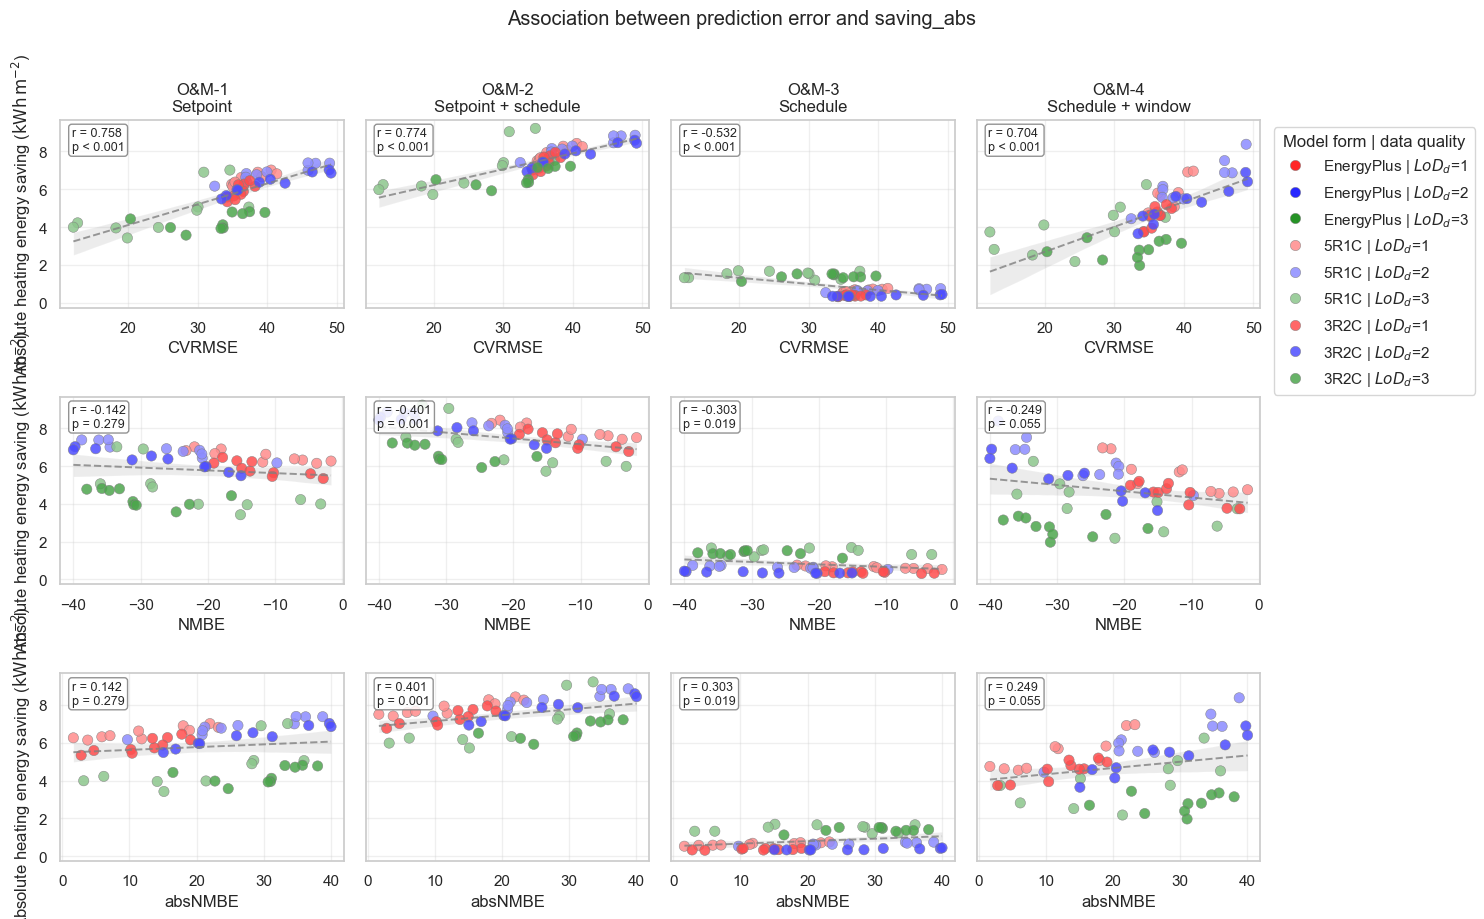

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


def _format_p_value(p):
    if pd.isna(p):
        return "p = NA"
    if p < 0.001:
        return "p < 0.001"
    return f"p = {p:.3f}"


def blend_with_white(colour, alpha):
    """
    alpha=1 gives the original colour.
    alpha=0 gives white.
    """
    rgb = mcolors.to_rgb(colour)
    return tuple(alpha * c + (1 - alpha) * 1.0 for c in rgb)


def plot_rq2_scatter_matrix(
    rq2_df,
    pearson_df=None,
    saving_metric="saving_abs",
    error_metrics=("CVRMSE", "NMBE", "absNMBE"),
    ecm_order=("O&M-1", "O&M-2", "O&M-3", "O&M-4"),
    engine_order=("EnergyPlus", "5R1C", "3R2C"),
    quality_order=("LoD-1", "LoD-2", "LoD-3"),
    quality_display_map=None,
    ecm_label_map=None,
    figsize=(15, 9),
):
    sns.set_theme(style="whitegrid")
    plt.rcParams["text.usetex"] = False

    if quality_display_map is None:
        quality_display_map = {
            "LoD-1": "$LoD_d$=1",
            "LoD-2": "$LoD_d$=2",
            "LoD-3": "$LoD_d$=3",
        }

    if ecm_label_map is None:
        ecm_label_map = {
            "O&M-1": "O&M-1\nSetpoint",
            "O&M-2": "O&M-2\nSetpoint + schedule",
            "O&M-3": "O&M-3\nSchedule",
            "O&M-4": "O&M-4\nSchedule + window",
        }

    saving_label_map = {
        "saving_abs": r"Absolute heating energy saving ($\mathrm{kWh\,m^{-2}}$)",
        "saving_rel": "Relative heating energy saving (%)",
    }

    # LoD base colours
    quality_base_colour = {
        "LoD-1": "red",
        "LoD-2": "blue",
        "LoD-3": "green",
    }

    # Engine shade intensity
    # 5R1C = lightest, 3R2C = medium, EnergyPlus = darkest
    engine_alpha = {
        "5R1C": 0.45,
        "3R2C": 0.70,
        "EnergyPlus": 1.00,
    }

    df = rq2_df.copy()

    df = df[
        df["ecm_common"].isin(ecm_order)
        & df["engine"].isin(engine_order)
        & df["data_quality"].isin(quality_order)
    ].copy()

    df["engine"] = pd.Categorical(
        df["engine"],
        categories=engine_order,
        ordered=True,
    )

    df["data_quality"] = pd.Categorical(
        df["data_quality"],
        categories=quality_order,
        ordered=True,
    )

    df["model_data"] = (
        df["engine"].astype(str)
        + " | "
        + df["data_quality"].astype(str)
    )

    model_data_order = [
        f"{engine} | {quality}"
        for engine in engine_order
        for quality in quality_order
    ]

    palette = {}

    for engine in engine_order:
        for quality in quality_order:
            key = f"{engine} | {quality}"
            palette[key] = blend_with_white(
                quality_base_colour[quality],
                engine_alpha[engine],
            )

    legend_label_map = {
        f"{engine} | {quality}": f"{engine} | {quality_display_map[quality]}"
        for engine in engine_order
        for quality in quality_order
    }

    df["model_data"] = pd.Categorical(
        df["model_data"],
        categories=model_data_order,
        ordered=True,
    )

    fig, axes = plt.subplots(
        nrows=len(error_metrics),
        ncols=len(ecm_order),
        figsize=figsize,
        sharey=True,
    )

    if len(error_metrics) == 1:
        axes = np.array([axes])

    for i, error_metric in enumerate(error_metrics):
        for j, ecm in enumerate(ecm_order):
            ax = axes[i, j]

            d = df[df["ecm_common"] == ecm].dropna(
                subset=[error_metric, saving_metric]
            )

            if d.empty:
                ax.text(
                    0.5,
                    0.5,
                    "No data",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                ax.set_axis_off()
                continue

            # Pooled regression line
            sns.regplot(
                data=d,
                x=error_metric,
                y=saving_metric,
                scatter=False,
                ax=ax,
                color="grey",
                line_kws={
                    "linewidth": 1.4,
                    "linestyle": "--",
                    "alpha": 0.8,
                },
            )

            # Scatter points with LoD colour and model-form shade
            sns.scatterplot(
                data=d,
                x=error_metric,
                y=saving_metric,
                hue="model_data",
                hue_order=model_data_order,
                palette=palette,
                s=55,
                alpha=0.85,
                edgecolor="grey",
                linewidth=0.4,
                ax=ax,
                legend=(i == 0 and j == len(ecm_order) - 1),
            )

            # Pearson annotation
            if pearson_df is not None:
                p_row = pearson_df[
                    (pearson_df["ecm_common"] == ecm)
                    & (pearson_df["Error metric"] == error_metric)
                    & (pearson_df["Saving metric"] == saving_metric)
                ]

                if not p_row.empty:
                    r = p_row.iloc[0]["Pearson r"]
                    p = p_row.iloc[0]["p_value"]

                    ax.text(
                        0.04,
                        0.96,
                        f"r = {r:.3f}\n{_format_p_value(p)}",
                        transform=ax.transAxes,
                        ha="left",
                        va="top",
                        fontsize=9,
                        bbox=dict(
                            boxstyle="round,pad=0.25",
                            facecolor="white",
                            edgecolor="grey",
                            alpha=0.85,
                        ),
                    )

            if i == 0:
                ax.set_title(ecm_label_map.get(ecm, ecm))

            if j == 0:
                ax.set_ylabel(
                    saving_label_map.get(saving_metric, saving_metric)
                )
            else:
                ax.set_ylabel("")

            ax.set_xlabel(error_metric)
            ax.grid(True, alpha=0.3)

            if ax.get_legend() is not None and not (
                i == 0 and j == len(ecm_order) - 1
            ):
                ax.get_legend().remove()

    # Legend
    if axes[0, -1].get_legend() is not None:
        handles, labels = axes[0, -1].get_legend_handles_labels()

        axes[0, -1].legend(
            handles,
            [legend_label_map.get(label, label) for label in labels],
            title="Model form | data quality",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            frameon=True,
        )

    fig.suptitle(
        f"Association between prediction error and {saving_metric}",
        y=1.02,
    )

    plt.tight_layout()
    plt.show()

    return fig, axes

rq2_pearson_ecm = run_rq2_pearson(
    rq2_df,
    group_cols=("ecm_common",),
)

fig_abs, axes_abs = plot_rq2_scatter_matrix(
    rq2_df,
    pearson_df=rq2_pearson_ecm,
    saving_metric="saving_abs",
)

In [13]:
rq2_pearson_gof = run_rq2_pearson(
    rq2_df,
    error_metrics=("GOF",),
    saving_metrics=("saving_abs", "saving_rel"),
    group_cols=("ecm_common",),
)

display(
    rq2_pearson_gof.assign(
        **{
            "Pearson r": lambda x: x["Pearson r"].round(3),
            "p_value": lambda x: x["p_value"].apply(
                lambda p: "< 0.001" if pd.notna(p) and p < 0.001 else f"{p:.3f}"
            ),
        }
    )
)

,ecm_common,Error metric,Saving metric,n,Pearson r,p_value,Significant
0,O&M-1,GOF,saving_abs,60,0.454,< 0.001,True
1,O&M-1,GOF,saving_rel,60,0.012,0.928,False
2,O&M-2,GOF,saving_abs,60,0.634,< 0.001,True
3,O&M-2,GOF,saving_rel,60,-0.171,0.192,False
4,O&M-3,GOF,saving_abs,60,-0.049,0.707,False
5,O&M-3,GOF,saving_rel,60,-0.204,0.117,False
6,O&M-4,GOF,saving_abs,60,0.499,< 0.001,True
7,O&M-4,GOF,saving_rel,60,0.240,0.064,False


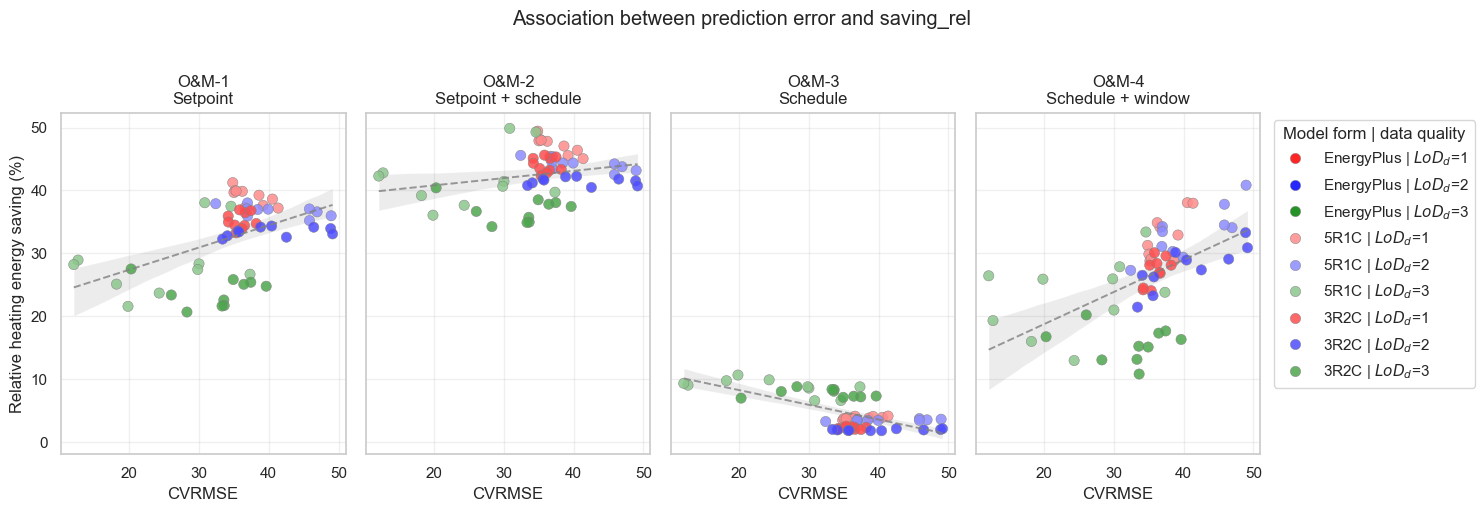

In [14]:
fig_gof_abs, axes_gof_abs = plot_rq2_scatter_matrix(
    rq2_df,
    pearson_df=rq2_pearson_gof,
    saving_metric="saving_rel",
    error_metrics=("CVRMSE",),
    figsize=(15, 5),
)